In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# Load the cleaned data
df = pd.read_csv("../data/cleaned/traffic_clean.csv", low_memory=False)
print(f'Loaded: {df.shape[0]} rows x {df.shape[1]} columns')

Loaded: 2070115 rows x 50 columns


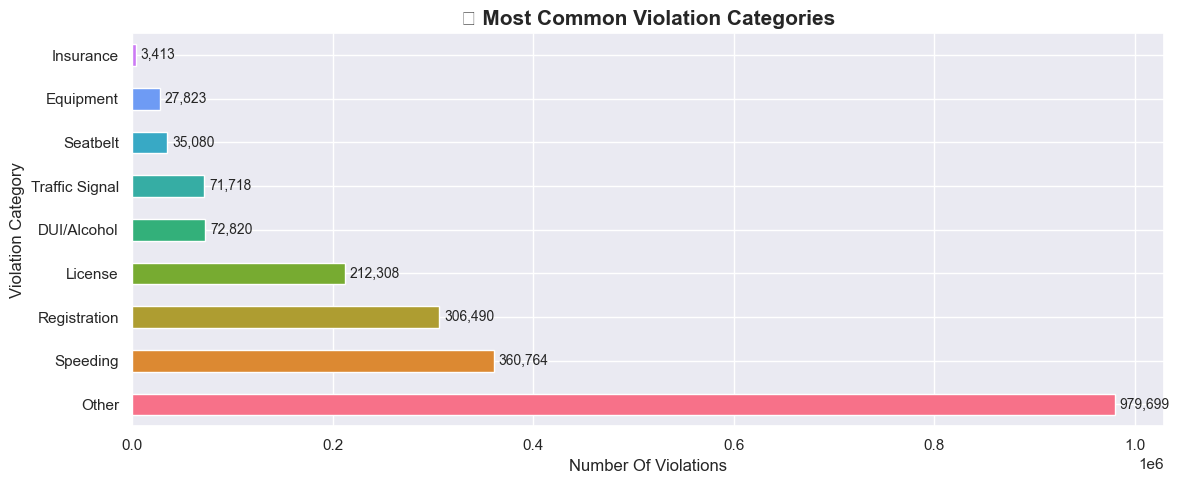

💡 Insight: 'Other' is large description keywords need expansion.
 Speeding accounts for 17.4% of all violations.


In [3]:
# Chart 1: Top Violation Categories

fig, ax = plt.subplots()
colors = sns.color_palette('husl', 10)

violation_category = df['ViolationCategory'].value_counts()
violation_category.plot(kind='barh', ax=ax, color=colors)

ax.set_title('🚦 Most Common Violation Categories', fontsize=15, fontweight='bold')
ax.set_xlabel('Number Of Violations')
ax.set_ylabel('Violation Category')

# Add value labels
for i, v in enumerate(violation_category.values):
    ax.text(v + 5000, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/cleaned/chart_violation_category.png', dpi=50)
plt.show()
print("💡 Insight: 'Other' is large description keywords need expansion.")
print(f" Speeding accounts for {violation_category['Speeding']/len(df)*100:.1f}% of all violations.")

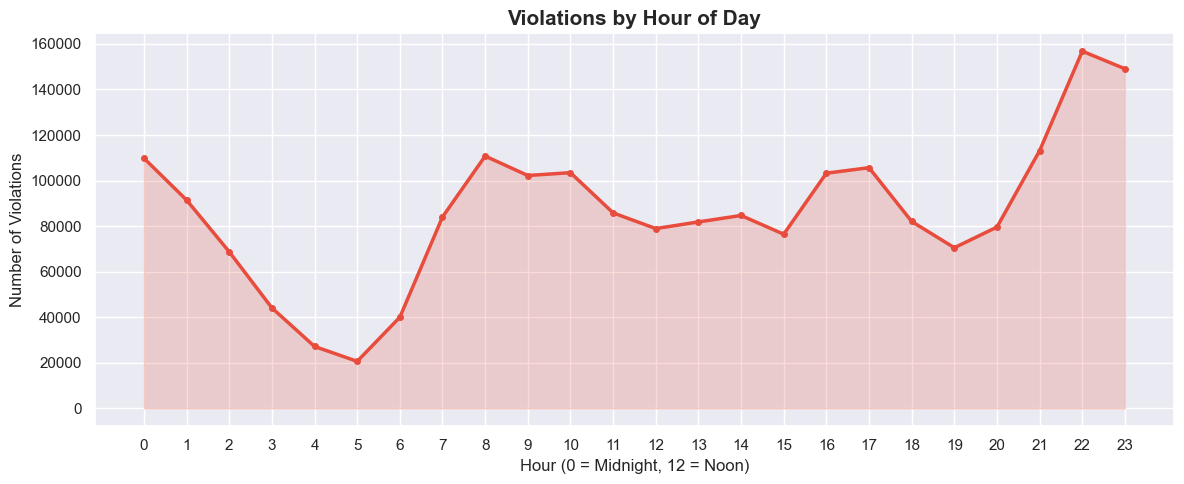

Insight: Peak violation hour is 22:00 with 156,808 violations.


In [4]:
# Chart 2: Violations By Hours Of Day
fig, ax = plt.subplots()
hourly = df['Hour'].value_counts().sort_index()
ax.plot(hourly.index, hourly.values, marker='o', color='#e74c3c', linewidth=2.5, markersize=4)
ax.fill_between(hourly.index, hourly.values, alpha=0.2, color='#e74c3c')

ax.set_title('Violations by Hour of Day', fontsize=15, fontweight='bold')
ax.set_xlabel('Hour (0 = Midnight, 12 = Noon)')
ax.set_ylabel('Number of Violations')
ax.set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('../data/cleaned/chart_hourly.png')
plt.show()

peak_hour = hourly.idxmax()
print(f'Insight: Peak violation hour is {peak_hour}:00 with {hourly.max():,} violations.')


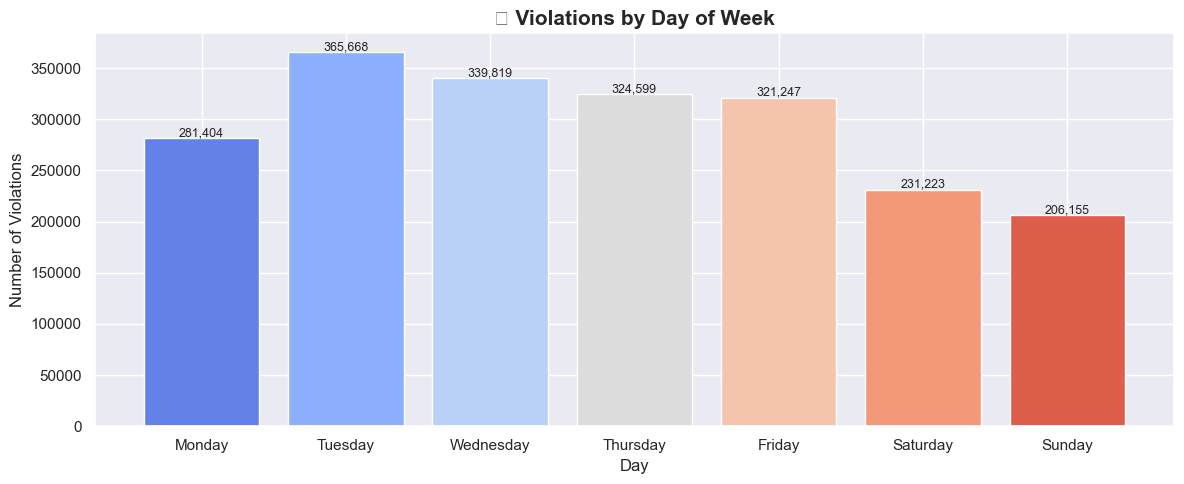

💡 Insight: Busiest day = Tuesday (365,668 violations)


In [5]:
# Chart 3: Violation by day of the week
fig, ax = plt.subplots()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df['DayOfWeek'].value_counts().reindex(day_order)

bars = ax.bar(daily.index, daily.values,
              color=sns.color_palette("coolwarm", 7))
ax.set_title('📅 Violations by Day of Week', fontsize=15, fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('Number of Violations')

for bar, val in zip(bars, daily.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'{val:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/cleaned/chart_daily.png', dpi=150)
plt.show()
print(f"💡 Insight: Busiest day = {daily.idxmax()} ({daily.max():,} violations)")

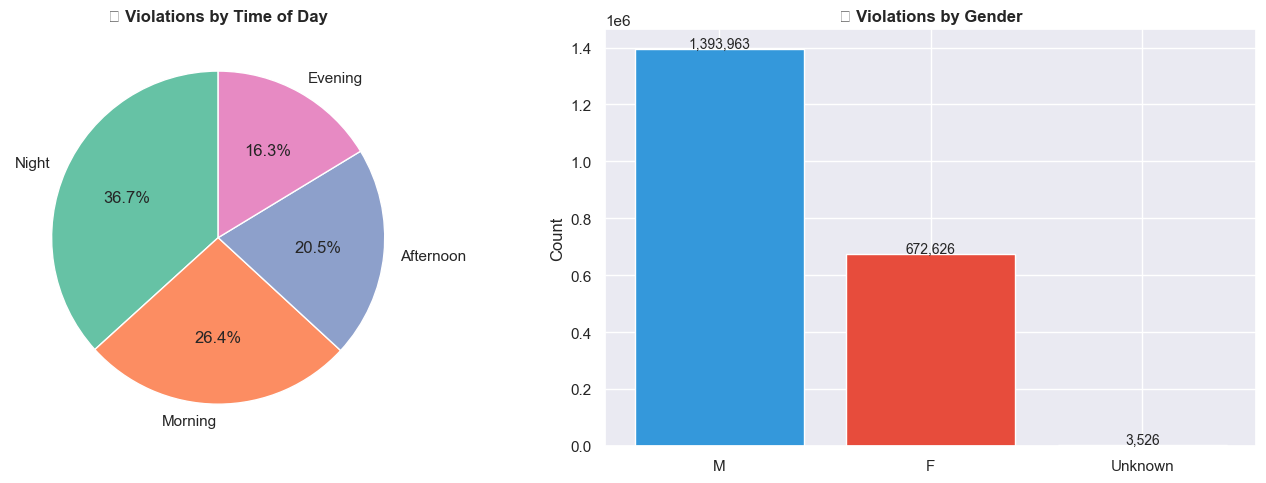

In [6]:
# Chart 4: Violation by Time of Day
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
tod = df['TimeOfDay'].value_counts()
axes[0].pie(tod.values, labels=tod.index, autopct='%1.1f%%',
            colors=sns.color_palette("Set2"), startangle=90)
axes[0].set_title('🌅 Violations by Time of Day', fontweight='bold')

# Gender breakdown
gender = df['Gender'].value_counts()
axes[1].bar(gender.index, gender.values,
            color=['#3498db','#e74c3c','#95a5a6'])
axes[1].set_title('👤 Violations by Gender', fontweight='bold')
axes[1].set_ylabel('Count')
for i, (idx, val) in enumerate(gender.items()):
    axes[1].text(i, val + 5000, f'{val:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/cleaned/chart_tod_gender.png', dpi=150)
plt.show()

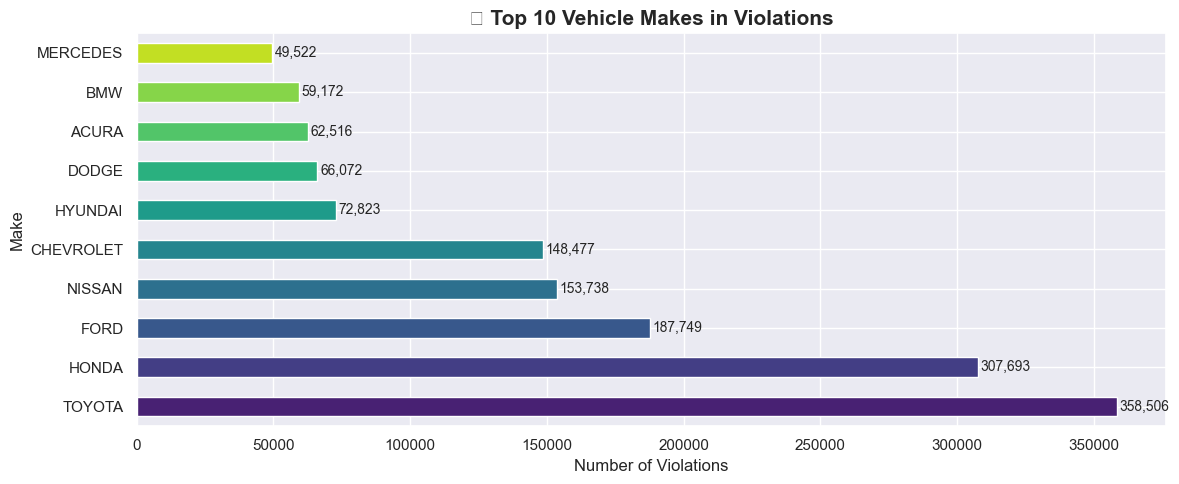

In [7]:
# Chart 5: Top 10 vechile make
fig, ax = plt.subplots()

top_makes = df['Make'].value_counts().head(10)
colors = sns.color_palette("viridis", 10)
top_makes.plot(kind='barh', ax=ax, color=colors)

ax.set_title('🚗 Top 10 Vehicle Makes in Violations', fontsize=15, fontweight='bold')
ax.set_xlabel('Number of Violations')
for i, v in enumerate(top_makes.values):
    ax.text(v + 1000, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/cleaned/chart_makes.png', dpi=150)
plt.show() 

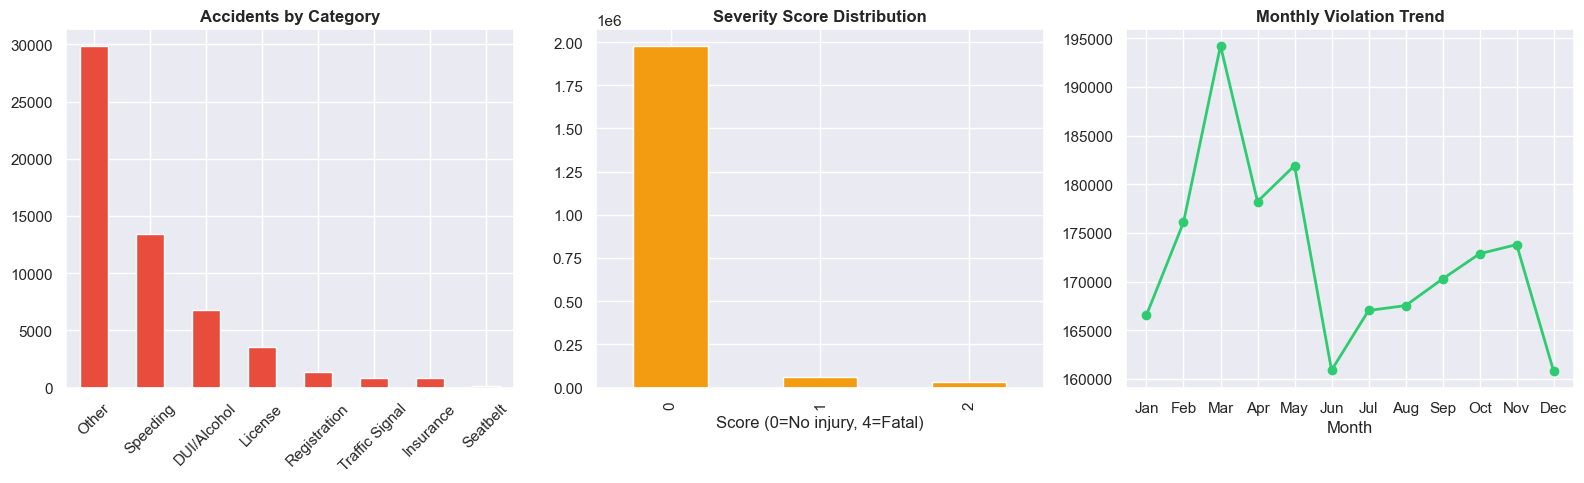

💡 56,683 violations involved accidents (2.74%)


In [8]:
# Chart 6: Accident related analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Accidents by violation category
acc = df[df['Accident'] == True]['ViolationCategory'].value_counts().head(8)
acc.plot(kind='bar', ax=axes[0], color='#e74c3c')
axes[0].set_title('Accidents by Category', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Severity score distribution
df['SeverityScore'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='#f39c12')
axes[1].set_title('Severity Score Distribution', fontweight='bold')
axes[1].set_xlabel('Score (0=No injury, 4=Fatal)')

# Monthly trend
monthly = df.groupby('Month').size()
monthly.plot(kind='line', ax=axes[2], marker='o', color='#2ecc71', linewidth=2)
axes[2].set_title('Monthly Violation Trend', fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_xticks(range(1,13))
axes[2].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])

plt.tight_layout()
plt.savefig('../data/cleaned/chart_accidents.png', dpi=150)
plt.show()

total_acc = df['Accident'].sum()
print(f"💡 {total_acc:,} violations involved accidents ({total_acc/len(df)*100:.2f}%)")

In [11]:
# Summary status
print("=" * 55)
print("       📊 EDA SUMMARY - KEY INSIGHTS")
print("=" * 55)
print(f"  Total violations        : {len(df):,}")
print(f"  Violations w/ accidents : {df['Accident'].sum():,}")
print(f"  Fatal violations        : {df['Fatal'].sum():,}")
print(f"  HAZMAT involved         : {df['HAZMAT'].sum():,}")
print(f"  Alcohol-related         : {df['Alcohol'].sum():,}")
print(f"  Most common violation   : {df['ViolationCategory'].mode()[0]}")
print(f"  Peak hour               : {int(df['Hour'].mode()[0])}:00")
print(f"  Busiest day             : {df['DayOfWeek'].mode()[0]}")
print(f"  Most cited vehicle      : {df['Make'].mode()[0]}")
print(f"  Most cited gender       : {df['Gender'].mode()[0]}")
print(f"  Date range              : {df['Date Of Stop'].min()} -> {df['Date Of Stop'].max()}")
print("=" * 55) 

       📊 EDA SUMMARY - KEY INSIGHTS
  Total violations        : 2,070,115
  Violations w/ accidents : 56,683
  Fatal violations        : 568
  HAZMAT involved         : 153
  Alcohol-related         : 2,622
  Most common violation   : Other
  Peak hour               : 22:00
  Busiest day             : Tuesday
  Most cited vehicle      : TOYOTA
  Most cited gender       : M
  Date range              : 2012-01-01 -> 2025-12-05
